#EMBEDDING SPACES

##0.REFERENCE

**Notebook title: Deep Neural Networks for Sentiment Classification and Word Embeddings**

**Introduction**

The IMDB movie review sentiment problem is one of the most useful introductory examples for teaching deep neural networks in natural language processing. The task is simple to state but conceptually rich: given a written movie review, the model must decide whether the review expresses a positive or negative opinion. Unlike the digits example, where each input was a small image represented by pixels, here each input is a sequence of words. This immediately introduces a new and extremely important problem in machine learning: how do we convert language into numbers?

A neural network cannot directly process words such as excellent, boring, brilliant, predictable, moving, or terrible. It requires numerical representations. A primitive approach would assign each word an arbitrary integer, but this is not enough. If excellent is represented by 42 and terrible is represented by 784, the numbers themselves do not tell the model anything about meaning. The number 42 is not semantically closer to brilliant than to boring. The integer code is only an identifier.

The key concept in this notebook is the embedding. An embedding layer learns a dense vector representation for each word. Instead of representing each word as a single arbitrary integer, the model represents each word as a vector of learned numerical coordinates. During training, words that behave similarly in the sentiment classification task tend to acquire related positions in this learned space. Words associated with positive reviews may move in one direction, words associated with negative reviews may move in another direction, and words with similar usage patterns may become close to each other.

This notebook uses the classical IMDB dataset included with Keras. The dataset contains movie reviews already converted into sequences of integer word identifiers. Each review has a binary label: positive or negative. We build a deep neural network with an embedding layer, a pooling layer, dense hidden layers, and a sigmoid output neuron. The sigmoid produces a probability that the review is positive.

The notebook also makes the embedding visible. After training, we extract the learned embedding matrix from the model. This matrix contains one vector per vocabulary term. Since embedding vectors may have many dimensions, we reduce them to two dimensions using principal component analysis. Then we create a scatter plot of selected words so students can see the idea of semantic proximity. We also compute nearest neighbors using cosine similarity, showing which words are close to a selected query word in the learned embedding space.

This is a pedagogical notebook. The objective is not to build the most powerful sentiment classifier possible. More advanced models would use recurrent networks, convolutional text models, transformers, or pretrained embeddings. Here we focus on the conceptual foundation: words become vectors, vectors enter a neural network, the network learns from labeled examples, and the learned geometry can be inspected. The IMDB problem is ideal because it connects language, sentiment, neural networks, and representation learning in a single compact example.

##1.LIBRARIES AND ENVIRONMENT

**Explanation for Cell 1**

This cell prepares the notebook environment. It imports the libraries, fixes random seeds, creates folders for outputs, and records a run manifest. The run manifest is useful because it preserves basic information about the experiment, including the TensorFlow version, the random seed, and the time of execution. This keeps the notebook disciplined and auditable.

In [1]:
import os
import re
import json
import random
import platform
import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_DIR = Path("/content/dnn_imdb_embedding_project")
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
MODEL_DIR = PROJECT_DIR / "model"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RUN_ID = datetime.datetime.now(datetime.timezone.utc).strftime("run_%Y%m%d_%H%M%S_utc")

environment_manifest = {
    "run_id": RUN_ID,
    "created_at_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
    "python_version": platform.python_version(),
    "platform": platform.platform(),
    "tensorflow_version": tf.__version__,
    "numpy_version": np.__version__,
    "seed": SEED
}

manifest_path = ARTIFACT_DIR / "run_manifest.json"

with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(environment_manifest, f, indent=2)

print("Run ID:", RUN_ID)
print("TensorFlow version:", tf.__version__)
print("Artifacts folder:", ARTIFACT_DIR)

Run ID: run_20260604_130752_utc
TensorFlow version: 2.20.0
Artifacts folder: /content/dnn_imdb_embedding_project/artifacts


##2.LOADING THE IMDB DATA

**Explanation for Cell 2**

This cell loads the IMDB movie review dataset from Keras. The reviews are already represented as sequences of integer word identifiers. We limit the vocabulary to the most frequent words so the model remains small and easy to teach. The cell also loads the word index, which allows us to translate integer identifiers back into readable words.

In [2]:
VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 250

(X_train_raw, y_train), (X_test_raw, y_test) = keras.datasets.imdb.load_data(
    num_words=VOCAB_SIZE
)

word_index = keras.datasets.imdb.get_word_index()

index_to_word = {
    index + 3: word
    for word, index in word_index.items()
}

index_to_word[0] = "<PAD>"
index_to_word[1] = "<START>"
index_to_word[2] = "<UNK>"
index_to_word[3] = "<UNUSED>"

word_to_index = {
    word: index
    for index, word in index_to_word.items()
}

dataset_summary = {
    "training_reviews": int(len(X_train_raw)),
    "test_reviews": int(len(X_test_raw)),
    "vocabulary_size_used": int(VOCAB_SIZE),
    "maximum_sequence_length": int(MAX_SEQUENCE_LENGTH),
    "label_meaning": {
        "0": "negative",
        "1": "positive"
    }
}

print(json.dumps(dataset_summary, indent=2))
print("Example raw review as integer tokens:")
print(X_train_raw[0][:30])
print("Example label:", int(y_train[0]))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
{
  "training_reviews": 25000,
  "test_reviews": 25000,
  "vocabulary_size_used": 10000,
  "maximum_sequence_length": 250,
  "label_meaning": {
    "0": "negative",
    "1": "positive"
  }
}
Example raw review as integer tokens:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480]
Example label: 1


##3.DATA INSPECTION

**Explanation for Cell 3**

This cell inspects the data before modeling. It decodes a few reviews back into approximate text and studies the length distribution of the reviews. This is important because text data is sequential and variable in length. Neural networks usually need batches with a common length, so we must understand how long the reviews are before padding or truncating them.

Length and label summary
{
  "minimum_length": 11,
  "median_length": 178.0,
  "mean_length": 238.71364,
  "maximum_length": 2494,
  "positive_training_reviews": 12500,
  "negative_training_reviews": 12500
}

Decoded review example
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and 

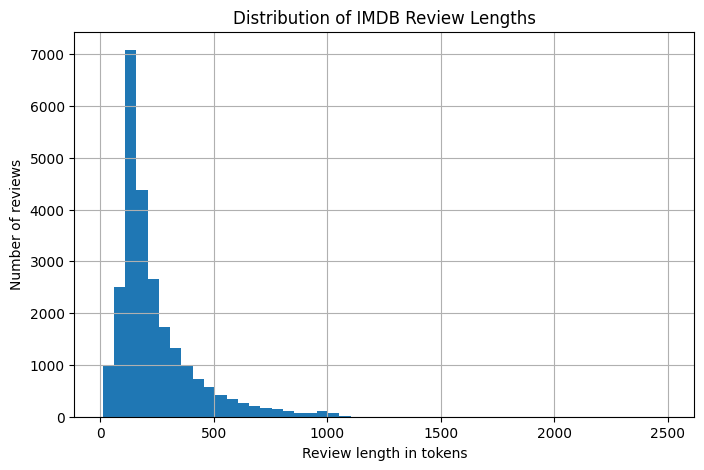

Saved review length distribution to: /content/dnn_imdb_embedding_project/artifacts/review_length_distribution.png


In [3]:
def decode_review(token_sequence):
    words = [
        index_to_word.get(token_id, "<UNK>")
        for token_id in token_sequence
    ]
    return " ".join(words)

review_lengths = np.array([len(review) for review in X_train_raw])

length_summary = {
    "minimum_length": int(np.min(review_lengths)),
    "median_length": float(np.median(review_lengths)),
    "mean_length": float(np.mean(review_lengths)),
    "maximum_length": int(np.max(review_lengths)),
    "positive_training_reviews": int(np.sum(y_train == 1)),
    "negative_training_reviews": int(np.sum(y_train == 0))
}

print("Length and label summary")
print(json.dumps(length_summary, indent=2))

print("\nDecoded review example")
print(decode_review(X_train_raw[0])[:1500])
print("\nLabel:", "positive" if y_train[0] == 1 else "negative")

plt.figure(figsize=(8, 5))
plt.hist(review_lengths, bins=50)
plt.xlabel("Review length in tokens")
plt.ylabel("Number of reviews")
plt.title("Distribution of IMDB Review Lengths")
plt.grid(True)

length_plot_path = ARTIFACT_DIR / "review_length_distribution.png"
plt.savefig(length_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved review length distribution to:", length_plot_path)

##4.DATA PREPROCESSING

**Explanation for Cell 4**

This cell pads and truncates the reviews so that every review has the same length. Short reviews receive padding tokens, while long reviews are truncated. This creates a rectangular matrix that can be processed efficiently by the neural network. The model will receive sequences of word identifiers, and the embedding layer will convert those identifiers into learned word vectors.

In [4]:
X_train = keras.preprocessing.sequence.pad_sequences(
    X_train_raw,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post",
    value=0
)

X_test = keras.preprocessing.sequence.pad_sequences(
    X_test_raw,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post",
    value=0
)

y_train = y_train.astype("float32")
y_test = y_test.astype("float32")

X_train_main, X_val = X_train[:20000], X_train[20000:]
y_train_main, y_val = y_train[:20000], y_train[20000:]

split_summary = {
    "training_samples": int(X_train_main.shape[0]),
    "validation_samples": int(X_val.shape[0]),
    "test_samples": int(X_test.shape[0]),
    "sequence_length": int(X_train_main.shape[1])
}

print(json.dumps(split_summary, indent=2))
print("Padded review shape:", X_train_main.shape)
print("First padded review, first 40 tokens:")
print(X_train_main[0][:40])

{
  "training_samples": 20000,
  "validation_samples": 5000,
  "test_samples": 25000,
  "sequence_length": 250
}
Padded review shape: (20000, 250)
First padded review, first 40 tokens:
[   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25  100   43  838  112   50  670    2    9
   35  480  284    5  150    4  172  112  167    2  336  385]


##5.THE TENSORFLOW DATASETS

**Explanation for Cell 5**

This cell creates TensorFlow datasets. The training dataset is shuffled, batched, and prefetched. Batching allows the model to process several reviews at a time. Shuffling prevents the model from learning accidental ordering patterns in the dataset. Prefetching helps the training loop run smoothly.

In [5]:
BATCH_SIZE = 64

train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train_main, y_train_main))
    .shuffle(buffer_size=len(X_train_main), seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_test, y_test))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

for batch_X, batch_y in train_ds.take(1):
    print("Input batch shape:", batch_X.shape)
    print("Label batch shape:", batch_y.shape)
    print("First labels in batch:", batch_y[:10].numpy())

Input batch shape: (64, 250)
Label batch shape: (64,)
First labels in batch: [1. 0. 0. 0. 0. 1. 0. 1. 1. 1.]


##6.DNN CONFIGURATION

**Explanation for Cell 6**

This cell builds the deep neural network. The most important layer is the embedding layer. It receives integer word identifiers and maps each word into a dense vector of learned coordinates. The pooling layer averages the word vectors across the review, producing one vector representation for the entire review. Dense layers then classify that review representation as positive or negative.

In [6]:
EMBEDDING_DIM = 32

def build_sentiment_embedding_dnn(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    sequence_length=MAX_SEQUENCE_LENGTH
):
    model = keras.Sequential(
        [
            layers.Input(shape=(sequence_length,), dtype="int32"),
            layers.Embedding(
                input_dim=vocab_size,
                output_dim=embedding_dim,
                name="word_embedding"
            ),
            layers.GlobalAveragePooling1D(name="average_review_embedding"),
            layers.Dense(64, activation="relu", name="dense_sentiment_1"),
            layers.Dropout(0.30),
            layers.Dense(32, activation="relu", name="dense_sentiment_2"),
            layers.Dropout(0.20),
            layers.Dense(1, activation="sigmoid", name="positive_probability")
        ],
        name="imdb_sentiment_embedding_dnn"
    )
    return model

model = build_sentiment_embedding_dnn()
model.summary()

Model: "imdb_sentiment_embedding_dnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ word_embedding (Embedding)      │ (None, 250, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_review_embedding        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_sentiment_1 (Dense)       │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_sentiment_2 (Dense)       │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positive_probability (Dense)    │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 324,225 (1.24 MB)

 Trainable params: 324,225 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

##7.COMPILATION AND TRAINING

---



**Explanation for Cell 7**

This cell compiles and trains the model. Binary cross-entropy is used because the problem has two classes: positive and negative. The model learns by adjusting both the sentiment classification layers and the embedding vectors. This is the essential teaching point: the word vectors are not manually assigned. They are learned from the classification task.

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping],
    verbose=1
)

history_dict = {
    key: [float(value) for value in values]
    for key, values in history.history.items()
}

history_path = ARTIFACT_DIR / "training_history.json"

with open(history_path, "w", encoding="utf-8") as f:
    json.dump(history_dict, f, indent=2)

print("Training history saved to:", history_path)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6836 - loss: 0.5726 - val_accuracy: 0.8168 - val_loss: 0.3977
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8616 - loss: 0.3331 - val_accuracy: 0.8660 - val_loss: 0.3202
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8961 - loss: 0.2667 - val_accuracy: 0.8162 - val_loss: 0.4027
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9128 - loss: 0.2277 - val_accuracy: 0.8782 - val_loss: 0.3144
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9282 - loss: 0.1980 - val_accuracy: 0.8744 - val_loss: 0.3398
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9336 - loss: 0.1854 - val_accuracy: 0.8808 - val_loss: 0.3277
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9495 - loss: 0.1482 - val_accuracy: 0.8728 - val_loss: 0.3691
Training history saved to: /content/dnn_imdb_embedding_project/artifacts/training_history.json


##8.MODEL EVALUATION

**Explanation for Cell 8**

This cell evaluates the model. First, it plots the training and validation curves. Then it evaluates the model on the test set and produces a confusion matrix and classification report. This allows students to see whether the model learned a useful sentiment classifier and whether it performs similarly on positive and negative reviews.

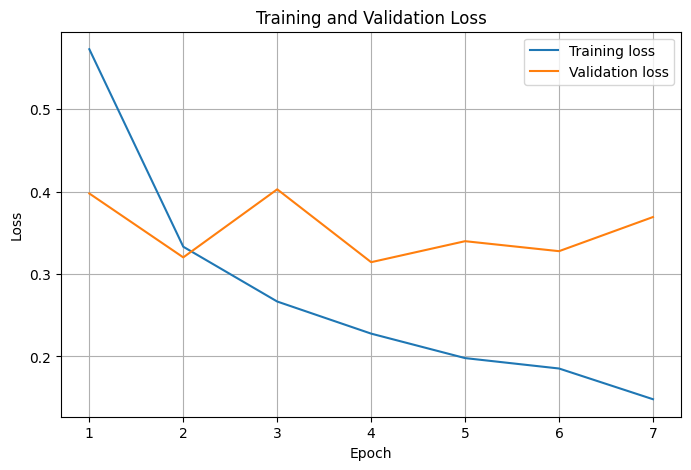

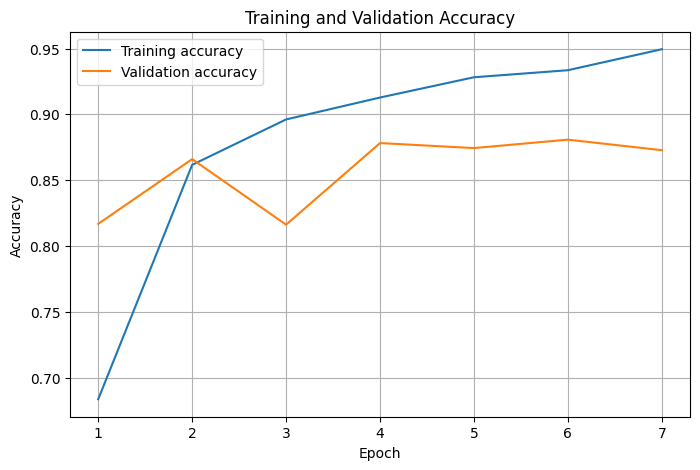

Test loss: 0.3404
Test accuracy: 0.8598

Classification report
              precision    recall  f1-score   support

    negative       0.83      0.90      0.87     12500
    positive       0.89      0.82      0.85     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



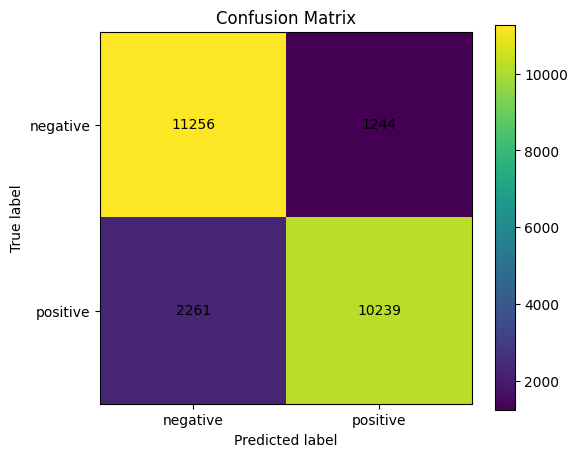

Saved evaluation summary to: /content/dnn_imdb_embedding_project/artifacts/evaluation_summary.json


In [8]:
epochs_ran = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history.history["loss"], label="Training loss")
plt.plot(epochs_ran, history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

loss_plot_path = ARTIFACT_DIR / "loss_curve.png"
plt.savefig(loss_plot_path, dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history.history["accuracy"], label="Training accuracy")
plt.plot(epochs_ran, history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

accuracy_plot_path = ARTIFACT_DIR / "accuracy_curve.png"
plt.savefig(accuracy_plot_path, dpi=150, bbox_inches="tight")
plt.show()

test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

y_prob = model.predict(X_test, verbose=0).reshape(-1)
y_pred = (y_prob >= 0.50).astype("int32")

cm = confusion_matrix(y_test.astype("int32"), y_pred)
report_text = classification_report(
    y_test.astype("int32"),
    y_pred,
    target_names=["negative", "positive"]
)

report_dict = classification_report(
    y_test.astype("int32"),
    y_pred,
    target_names=["negative", "positive"],
    output_dict=True
)

evaluation_summary = {
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "classification_report": report_dict,
    "confusion_matrix": cm.tolist()
}

evaluation_path = ARTIFACT_DIR / "evaluation_summary.json"

with open(evaluation_path, "w", encoding="utf-8") as f:
    json.dump(evaluation_summary, f, indent=2)

print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_accuracy, 4))
print("\nClassification report")
print(report_text)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["negative", "positive"])
plt.yticks([0, 1], ["negative", "positive"])
plt.xlabel("Predicted label")
plt.ylabel("True label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

confusion_matrix_path = ARTIFACT_DIR / "confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved evaluation summary to:", evaluation_path)

##9.VISUALIZATION OF THE EMBEDDING LAYER

**Explanation for Cell 9**

This cell extracts the learned embedding matrix from the trained model. Each row of the matrix is the learned vector for one word identifier. Since the vectors have many dimensions, we use principal component analysis to reduce them to two dimensions. The resulting plot is not a perfect map of meaning, but it gives students a visual intuition: words can be represented as points in a learned semantic space.

Embedding matrix shape: (10000, 32)


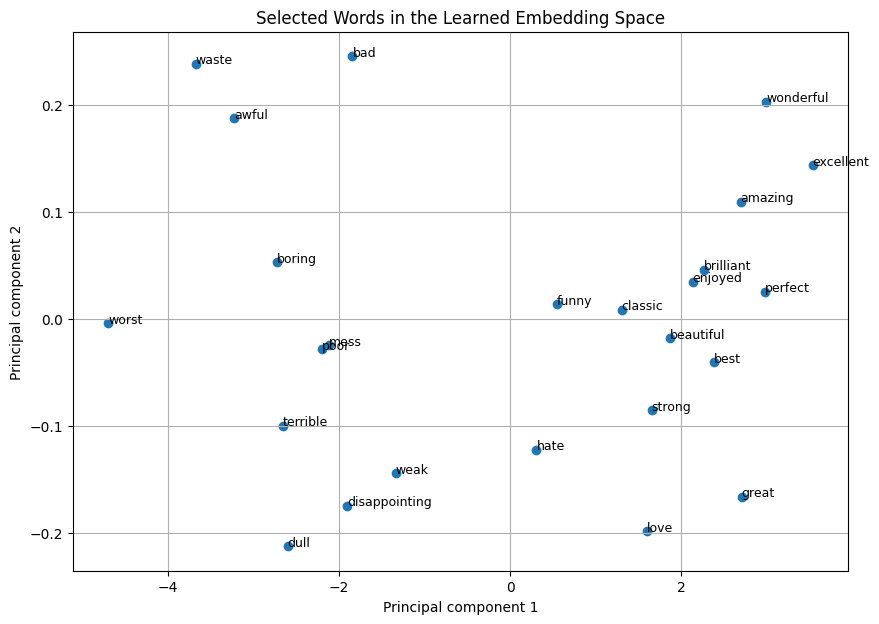

Saved selected word embedding coordinates to: /content/dnn_imdb_embedding_project/artifacts/selected_word_embedding_coordinates.json
Saved selected word embedding plot to: /content/dnn_imdb_embedding_project/artifacts/selected_word_embedding_plot.png


In [9]:
embedding_layer = model.get_layer("word_embedding")
embedding_matrix = embedding_layer.get_weights()[0]

print("Embedding matrix shape:", embedding_matrix.shape)

candidate_words = [
    "excellent", "great", "amazing", "wonderful", "brilliant",
    "bad", "terrible", "awful", "boring", "waste",
    "funny", "beautiful", "poor", "dull", "perfect",
    "worst", "best", "love", "hate", "enjoyed",
    "disappointing", "classic", "mess", "strong", "weak"
]

selected_words = []
selected_indices = []

for word in candidate_words:
    index = word_to_index.get(word)
    if index is not None and index < VOCAB_SIZE:
        selected_words.append(word)
        selected_indices.append(index)

selected_vectors = embedding_matrix[selected_indices]

pca = PCA(n_components=2, random_state=SEED)
selected_vectors_2d = pca.fit_transform(selected_vectors)

embedding_visualization_records = []

for word, index, coordinates in zip(selected_words, selected_indices, selected_vectors_2d):
    embedding_visualization_records.append(
        {
            "word": word,
            "index": int(index),
            "x": float(coordinates[0]),
            "y": float(coordinates[1])
        }
    )

embedding_visualization_path = ARTIFACT_DIR / "selected_word_embedding_coordinates.json"

with open(embedding_visualization_path, "w", encoding="utf-8") as f:
    json.dump(embedding_visualization_records, f, indent=2)

plt.figure(figsize=(10, 7))
plt.scatter(selected_vectors_2d[:, 0], selected_vectors_2d[:, 1])

for word, coordinates in zip(selected_words, selected_vectors_2d):
    plt.annotate(word, (coordinates[0], coordinates[1]), fontsize=9)

plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title("Selected Words in the Learned Embedding Space")
plt.grid(True)

selected_embedding_plot_path = ARTIFACT_DIR / "selected_word_embedding_plot.png"
plt.savefig(selected_embedding_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved selected word embedding coordinates to:", embedding_visualization_path)
print("Saved selected word embedding plot to:", selected_embedding_plot_path)

###9.1.CLUSTERED WORD EMBEDDING PLOT

Let's visualize the word embeddings in 3D with more clusters to gain further insights into their relationships.

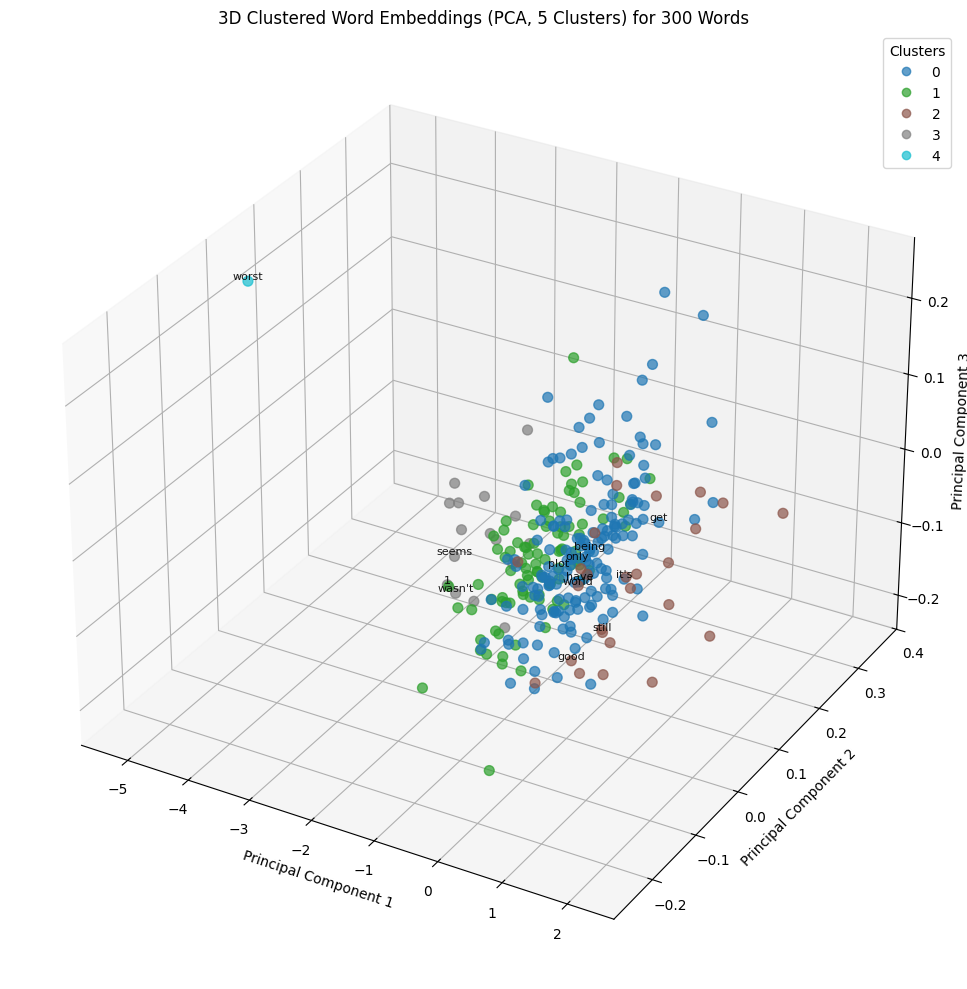

Saved 3D clustered embedding plot to: /content/dnn_imdb_embedding_project/artifacts/clustered_300_words_embedding_plot_3d.png


In [11]:
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D

num_words_to_plot_3d = 300
num_clusters_3d = 5 # Increased number of clusters for better separation

selected_words_for_clustering_3d = []
selected_indices_for_clustering_3d = []

# Reuse the logic to select words, ensuring unique indices and within VOCAB_SIZE
for idx in range(4, VOCAB_SIZE):
    if idx in index_to_word: # Check if the index corresponds to a word
        word = index_to_word[idx]
        selected_words_for_clustering_3d.append(word)
        selected_indices_for_clustering_3d.append(idx)
        if len(selected_words_for_clustering_3d) >= num_words_to_plot_3d:
            break

if len(selected_words_for_clustering_3d) < num_words_to_plot_3d:
    print(f"Warning: Could only find {len(selected_words_for_clustering_3d)} unique words for 3D plotting.")
    num_words_to_plot_3d = len(selected_words_for_clustering_3d)

words_to_cluster_vectors_3d = embedding_matrix[selected_indices_for_clustering_3d]

# Reduce dimensions to 3 using PCA
pca_clustering_3d = PCA(n_components=3, random_state=SEED)
words_to_cluster_vectors_3d_pca = pca_clustering_3d.fit_transform(words_to_cluster_vectors_3d)

# Perform KMeans clustering on the 3D data
kmeans_3d = KMeans(n_clusters=num_clusters_3d, random_state=SEED, n_init=10)
cluster_labels_3d = kmeans_3d.fit_predict(words_to_cluster_vectors_3d_pca)

# Create 3D plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

scatter_3d = ax.scatter(
    words_to_cluster_vectors_3d_pca[:, 0],
    words_to_cluster_vectors_3d_pca[:, 1],
    words_to_cluster_vectors_3d_pca[:, 2],
    c=cluster_labels_3d,
    cmap="tab10", # Use a different colormap for more clusters
    alpha=0.7,
    s=50
)

# Annotate a subset of words to avoid clutter
annotated_words_per_cluster_3d = 3 # Annotate fewer words in 3D for readability
annotated_indices_3d = []
for cluster_id in range(num_clusters_3d):
    cluster_points_original_indices_3d = np.where(cluster_labels_3d == cluster_id)[0]
    if len(cluster_points_original_indices_3d) > annotated_words_per_cluster_3d:
        selected_for_annotation_3d = np.random.choice(
            cluster_points_original_indices_3d,
            annotated_words_per_cluster_3d,
            replace=False
        )
    else:
        selected_for_annotation_3d = cluster_points_original_indices_3d
    annotated_indices_3d.extend(selected_for_annotation_3d)

for i in annotated_indices_3d:
    word = selected_words_for_clustering_3d[i]
    x, y, z = words_to_cluster_vectors_3d_pca[i]
    ax.text(x, y, z, word, fontsize=8, alpha=0.9, ha='center', va='bottom')

ax.set_title(f"3D Clustered Word Embeddings (PCA, {num_clusters_3d} Clusters) for {num_words_to_plot_3d} Words")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.legend(*scatter_3d.legend_elements(), title="Clusters")

plt.tight_layout()
clustered_embedding_plot_3d_path = ARTIFACT_DIR / f"clustered_{num_words_to_plot_3d}_words_embedding_plot_3d.png"
plt.savefig(clustered_embedding_plot_3d_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved 3D clustered embedding plot to: {clustered_embedding_plot_3d_path}")

###9.2.INTERACTIVE 3D WORD EMBEDDING PLOT

To allow for interactive exploration with mouseovers, we can use Plotly to create a dynamic 3D scatter plot of the word embeddings. This will let you see the word associated with each point by hovering over it.

In [14]:
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd

# Reuse the PCA-reduced 3D data and cluster labels from the previous cell
# words_to_cluster_vectors_3d_pca
# cluster_labels_3d
# selected_words_for_clustering_3d

# Create a DataFrame for Plotly for easier handling
plotly_df = pd.DataFrame({
    'PC1': words_to_cluster_vectors_3d_pca[:, 0],
    'PC2': words_to_cluster_vectors_3d_pca[:, 1],
    'PC3': words_to_cluster_vectors_3d_pca[:, 2],
    'Word': selected_words_for_clustering_3d,
    'Cluster': cluster_labels_3d
})

fig = px.scatter_3d(plotly_df,
                    x='PC1', y='PC2', z='PC3',
                    color='Cluster',
                    hover_name='Word',
                    title=f"Interactive 3D Clustered Word Embeddings ({num_clusters_3d} Clusters)",
                    color_continuous_scale=px.colors.sequential.Viridis)

fig.update_layout(scene = dict(
                    xaxis_title='Principal Component 1',
                    yaxis_title='Principal Component 2',
                    zaxis_title='Principal Component 3'))

fig.show()

##10.SEMANTIC NEIGHBORS

**Explanation for Cell 10**

This cell computes semantic neighbors in the learned embedding space. For a query word, it calculates cosine similarity between that word vector and all other word vectors. The closest words are then displayed. This is the most direct way to teach embedding similarity: words are close when their learned vectors point in similar directions. The cell also saves the trained model and the nearest-neighbor results as artifacts.

In [15]:
def clean_candidate_word(word):
    return bool(re.match(r"^[a-zA-Z]+$", word))

def nearest_words(query_word, top_n=10):
    query_index = word_to_index.get(query_word)

    if query_index is None or query_index >= VOCAB_SIZE:
        return {
            "query_word": query_word,
            "available": False,
            "neighbors": []
        }

    query_vector = embedding_matrix[query_index].reshape(1, -1)
    similarities = cosine_similarity(query_vector, embedding_matrix)[0]

    sorted_indices = np.argsort(similarities)[::-1]

    neighbors = []

    for candidate_index in sorted_indices:
        candidate_word = index_to_word.get(int(candidate_index), "<UNK>")

        if candidate_index == query_index:
            continue

        if candidate_index < 4:
            continue

        if not clean_candidate_word(candidate_word):
            continue

        neighbors.append(
            {
                "word": candidate_word,
                "index": int(candidate_index),
                "cosine_similarity": float(similarities[candidate_index])
            }
        )

        if len(neighbors) >= top_n:
            break

    return {
        "query_word": query_word,
        "available": True,
        "neighbors": neighbors
    }

query_words = ["excellent", "terrible", "boring", "beautiful", "worst", "best"]

nearest_neighbor_results = [
    nearest_words(query_word, top_n=10)
    for query_word in query_words
]

nearest_neighbors_path = ARTIFACT_DIR / "nearest_embedding_neighbors.json"

with open(nearest_neighbors_path, "w", encoding="utf-8") as f:
    json.dump(nearest_neighbor_results, f, indent=2)

for result in nearest_neighbor_results:
    print("\nQuery word:", result["query_word"])

    if not result["available"]:
        print("Word not available in selected vocabulary.")
        continue

    for neighbor in result["neighbors"]:
        print(
            neighbor["word"],
            "similarity:",
            round(neighbor["cosine_similarity"], 4)
        )

model_path = MODEL_DIR / "imdb_sentiment_embedding_dnn.keras"
model.save(model_path)

print("\nSaved nearest-neighbor results to:", nearest_neighbors_path)
print("Saved model to:", model_path)


Query word: excellent
enjoy similarity: 0.9964
highly similarity: 0.9945
superb similarity: 0.9941
touching similarity: 0.9937
wonderful similarity: 0.9937
fantastic similarity: 0.9935
loved similarity: 0.9935
today similarity: 0.9934
excellently similarity: 0.9934
wonderfully similarity: 0.9934

Query word: terrible
worst similarity: 0.9977
annoying similarity: 0.9977
boring similarity: 0.9966
dull similarity: 0.9965
disappointment similarity: 0.9962
badly similarity: 0.9961
poorly similarity: 0.996
poor similarity: 0.9959
tedious similarity: 0.9959
mess similarity: 0.9958

Query word: boring
badly similarity: 0.9975
worst similarity: 0.9975
tedious similarity: 0.9971
mess similarity: 0.9968
awful similarity: 0.9967
terrible similarity: 0.9966
pointless similarity: 0.9966
predictable similarity: 0.9966
waste similarity: 0.9966
poor similarity: 0.9962

Query word: beautiful
believable similarity: 0.9838
vivid similarity: 0.9837
great similarity: 0.9821
today similarity: 0.9819
enjoyed

##11.EXPLANATION AND SUMMARIZATION

**Explanation for the LLM Results Cell**

This cell uses an OpenAI language model to explain the model and its results. It reads the saved evaluation summary, training history, and embedding-neighbor artifacts. The LLM is instructed to produce strict JSON and to separate facts from interpretation. The API key is expected to be stored in Colab Secrets under OPENAI_API_KEY.

In [16]:
import re
from google.colab import userdata
from openai import OpenAI

OPENAI_MODEL = "gpt-5.2"

api_key = userdata.get("OPENAI_API_KEY")

if not api_key:
    raise ValueError("OPENAI_API_KEY was not found in Colab Secrets.")

client = OpenAI(api_key=api_key)

with open(evaluation_path, "r", encoding="utf-8") as f:
    evaluation_for_llm = json.load(f)

with open(history_path, "r", encoding="utf-8") as f:
    history_for_llm = json.load(f)

with open(nearest_neighbors_path, "r", encoding="utf-8") as f:
    neighbors_for_llm = json.load(f)

compact_results = {
    "run_id": RUN_ID,
    "dataset_summary": dataset_summary,
    "split_summary": split_summary,
    "model_name": model.name,
    "embedding_dimension": EMBEDDING_DIM,
    "epochs_completed": len(history_for_llm["loss"]),
    "final_training_loss": history_for_llm["loss"][-1],
    "final_validation_loss": history_for_llm["val_loss"][-1],
    "final_training_accuracy": history_for_llm["accuracy"][-1],
    "final_validation_accuracy": history_for_llm["val_accuracy"][-1],
    "test_loss": evaluation_for_llm["test_loss"],
    "test_accuracy": evaluation_for_llm["test_accuracy"],
    "classification_report": evaluation_for_llm["classification_report"],
    "confusion_matrix": evaluation_for_llm["confusion_matrix"],
    "nearest_embedding_neighbors": neighbors_for_llm
}

system_prompt = """
You are a machine learning instructor.
Explain a deep neural network sentiment model and the concept of word embeddings.
Return strict JSON only.
Do not invent results.
Separate observed facts from interpretation.
"""

user_prompt = f"""
Analyze the following experiment results.

Return JSON with this schema:

{{
  "plain_english_summary": "string",
  "sentiment_model_explanation": "string",
  "embedding_explanation": "string",
  "results_explanation": "string",
  "what_the_embedding_neighbors_show": "string",
  "evidence_used": ["string"],
  "assumptions": ["string"],
  "limitations": ["string"],
  "recommended_next_steps": ["string"],
  "verification_status": "Not verified by external data"
}}

Experiment results:

BEGIN_RESULTS_JSON
{json.dumps(compact_results, indent=2)}
END_RESULTS_JSON
"""

response = client.responses.create(
    model=OPENAI_MODEL,
    input=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
)

llm_text = response.output_text.strip()

def extract_json_object(text):
    text = text.strip()
    text = re.sub(r"^```json\s*", "", text)
    text = re.sub(r"^```\s*", "", text)
    text = re.sub(r"\s*```$", "", text)

    first = text.find("{")
    last = text.rfind("}")

    if first == -1 or last == -1 or last <= first:
        raise ValueError("No JSON object found in LLM response.")

    candidate = text[first:last + 1]
    return json.loads(candidate)

llm_explanation = extract_json_object(llm_text)

llm_explanation_path = ARTIFACT_DIR / "llm_results_explanation.json"

with open(llm_explanation_path, "w", encoding="utf-8") as f:
    json.dump(llm_explanation, f, indent=2)

print(json.dumps(llm_explanation, indent=2))
print("\nLLM explanation saved to:", llm_explanation_path)

{
  "plain_english_summary": "A sentiment classifier was trained on 20,000 IMDB reviews (with 5,000 for validation) using a 10,000-word vocabulary and 250-token sequences. It achieves 85.98% test accuracy. The training accuracy (94.95%) is notably higher than validation (87.28%) and test (85.98%), and the validation loss (0.369) is higher than the training loss (0.148), which is consistent with some overfitting. The model is better at catching negative reviews (negative recall 0.900) than catching positive reviews (positive recall 0.819).",
  "sentiment_model_explanation": "A deep neural network (DNN) sentiment model typically works as: (1) tokenize each review into word indices from a fixed vocabulary, truncating/padding to a maximum length (here 250 tokens); (2) map each word index to a dense vector via an embedding layer (here 32 dimensions); (3) combine the sequence of embeddings into a single representation using one or more neural layers (commonly pooling, recurrent layers, or 1D

##12.CONCLUSIONS

**Conclusion**

This notebook introduced deep neural networks for sentiment classification and used the IMDB movie review problem to teach the concept of word embeddings. The central challenge was different from the handwritten digits problem. In the digits case, the input was already numerical because images can be represented directly as pixel values. In the sentiment case, the input begins as language. Words must be converted into numbers before a neural network can learn from them.

The notebook showed why simple integer encoding is not enough. Integer identifiers allow the computer to store words, but they do not carry semantic meaning by themselves. The word excellent may have one integer code, while the word terrible may have another, but the distance between those integers is meaningless. The embedding layer solves this problem by learning a vector representation for each word. These vectors are adjusted during training so that they become useful for the classification task.

The model used a compact architecture: an embedding layer, a global average pooling layer, dense hidden layers, dropout regularization, and a sigmoid output layer. The embedding layer transformed each review from a sequence of word identifiers into a sequence of word vectors. The pooling layer summarized the review into a single average representation. The dense layers then used that representation to estimate the probability that the review was positive.

This structure is intentionally simple. It does not understand grammar deeply, and it does not preserve word order after the average pooling step. However, it is ideal for teaching. Students can see that even a simple learned representation of words can produce meaningful sentiment classification performance. They can also see that the model is not merely memorizing a dictionary of positive and negative words. It learns a geometry of language from many labeled examples.

The most important conceptual artifact is the embedding visualization. After training, the notebook extracts the embedding matrix and projects selected word vectors into two dimensions using principal component analysis. This gives students a visual intuition for the idea that words can occupy positions in a learned semantic space. The nearest-neighbor analysis makes the idea even more concrete. For a query word such as excellent or terrible, the notebook finds the words whose vectors are closest by cosine similarity. These neighbors are not guaranteed to be perfect synonyms, because the embedding is trained only for the sentiment task, but they demonstrate how semantic and task-based similarity can emerge from training.

The LLM explanation cell extends the notebook into a governed AI workflow. The neural network produces numerical results and learned embeddings. The language model explains those results in structured JSON, separating evidence, assumptions, limitations, and recommended next steps. This reinforces the broader teaching pattern of the project: machine learning systems should not only compute; they should also produce auditable artifacts that humans can inspect.

This notebook is therefore a natural second example in the deep learning sequence. The digits notebook teaches neural networks on numerical image data. The IMDB notebook teaches neural networks on language data. Together, they show that deep learning is not one single technique tied to one type of input. It is a general representational framework. Pixels can become features. Words can become embeddings. Reviews can become vectors. And once real-world objects become vectors, neural networks can begin to learn patterns from them.